In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

pd.set_option('display.max_columns', None)

# Load and Merge

In [7]:
path = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/"

train = pd.read_csv(path + 'train.csv.zip', parse_dates=['Date'])
features = pd.read_csv(path + 'features.csv.zip', parse_dates=['Date'])
stores = pd.read_csv(path + 'stores.csv')

df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')

print(df.shape)
df.head()

(421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [9]:
print("Unique stores:", df['Store'].nunique())
print("Unique departments:", df['Dept'].nunique())
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Number of unique weeks:", df['Date'].nunique())

Unique stores: 45
Unique departments: 81
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Number of unique weeks: 143


In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct.round(2)}).sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
MarkDown2,310322,73.61
MarkDown4,286603,67.98
MarkDown3,284479,67.48
MarkDown1,270889,64.26
MarkDown5,270138,64.08
Store,0,0.00
Date,0,0.00
Dept,0,0.00
Fuel_Price,0,0.00
Temperature,0,0.00


# MarkDown Missingness Over Time

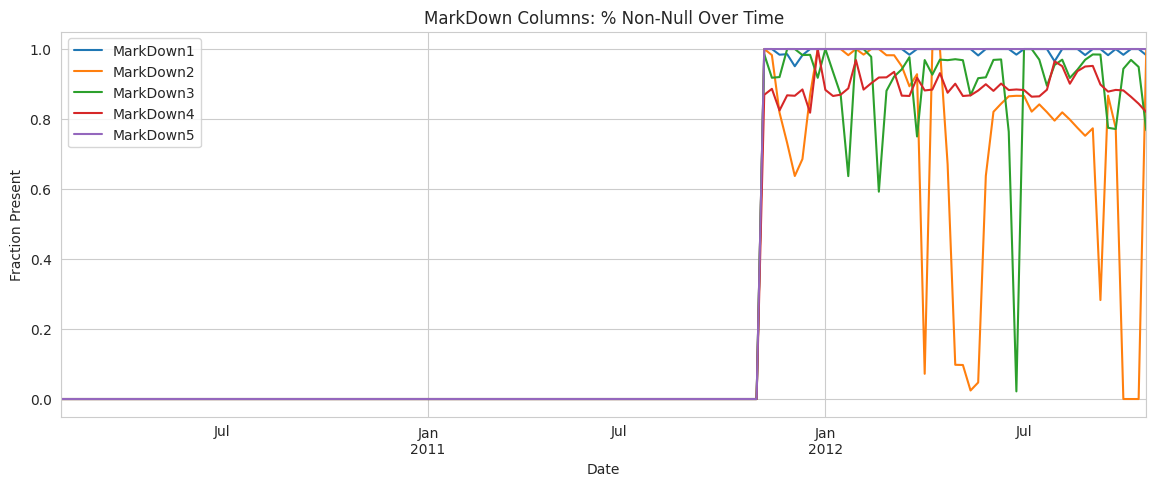

In [11]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

markdown_presence = df.groupby('Date')[markdown_cols].apply(lambda x: x.notnull().mean())
markdown_presence.plot(figsize=(14, 5), title='MarkDown Columns: % Non-Null Over Time')
plt.ylabel('Fraction Present')
plt.show()

# Target Variable Distribution

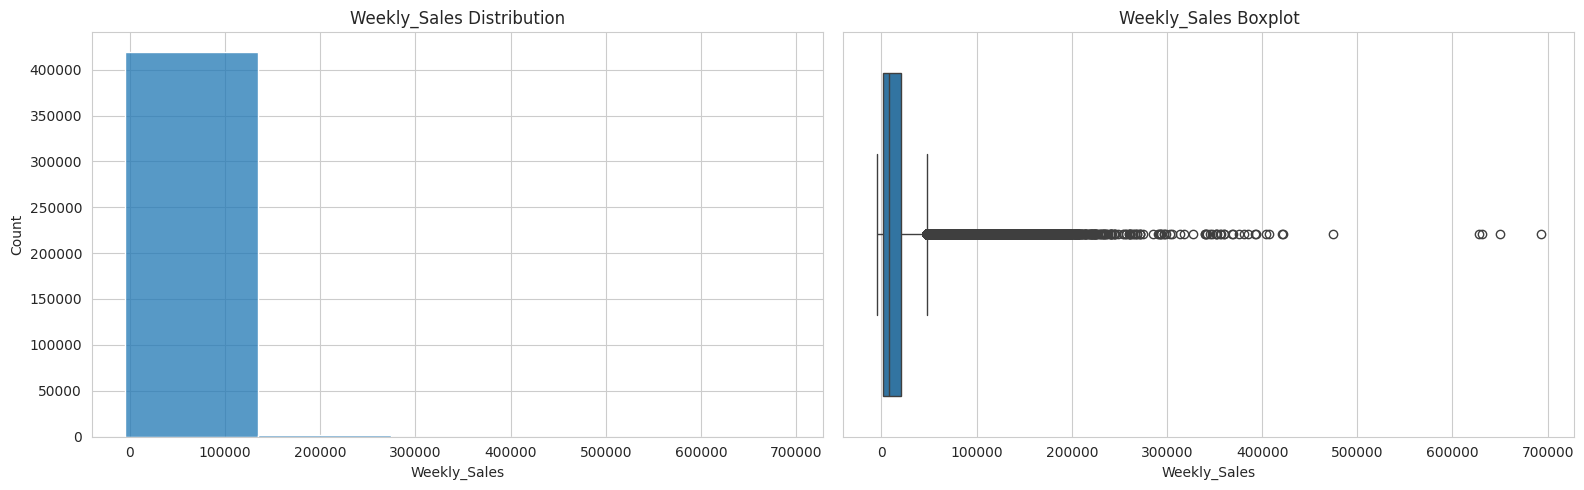

Negative sales rows: 1285
Min sales: -4988.94
Max sales: 693099.36


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['Weekly_Sales'], bins=5, ax=axes[0])
axes[0].set_title('Weekly_Sales Distribution')

sns.boxplot(x=df['Weekly_Sales'], ax=axes[1])
axes[1].set_title('Weekly_Sales Boxplot')

plt.tight_layout()
plt.show()

print("Negative sales rows:", (df['Weekly_Sales'] < 0).sum())
print("Min sales:", df['Weekly_Sales'].min())
print("Max sales:", df['Weekly_Sales'].max())

In [22]:
df[df['Weekly_Sales'] < 0][['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']].sort_values('Weekly_Sales').head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday
267730,28,6,2010-10-08,-4988.94,False
336495,35,47,2011-09-02,-3924.00,False
417801,45,47,2010-02-26,-1750.00,False
153916,16,47,2012-03-09,-1699.00,False
271300,28,32,2011-03-25,-1321.48,False
16291,2,47,2010-07-30,-1098.00,False
16295,2,47,2010-10-15,-1098.00,False
16297,2,47,2010-11-19,-1098.00,False
24830,3,32,2011-09-30,-1008.96,False
35561,4,47,2010-09-17,-898.00,False


# Aggregate Sales Over Time

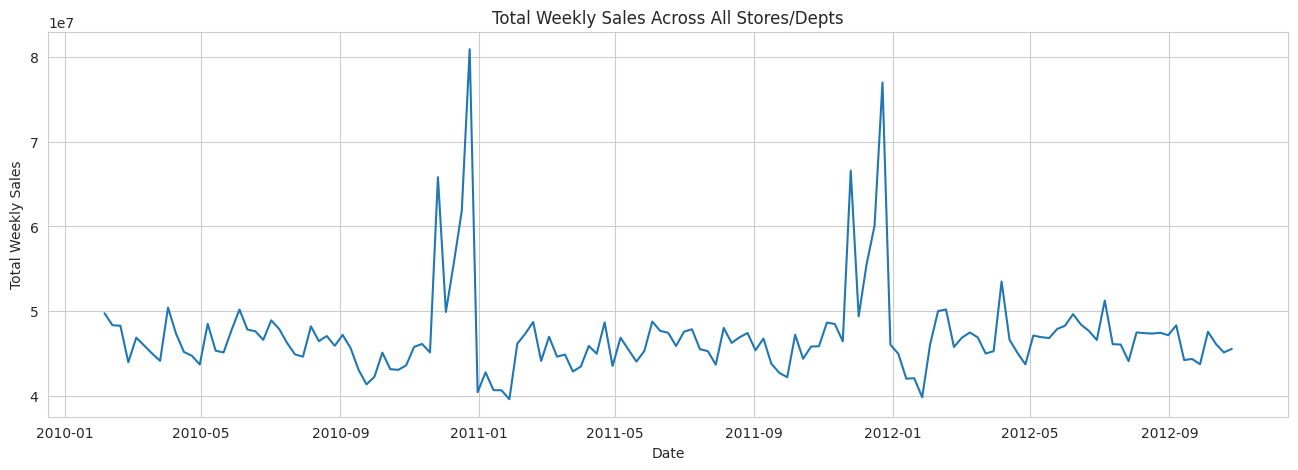

In [23]:
weekly_total = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'])
plt.title('Total Weekly Sales Across All Stores/Depts')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.show()

# Holiday Effect

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


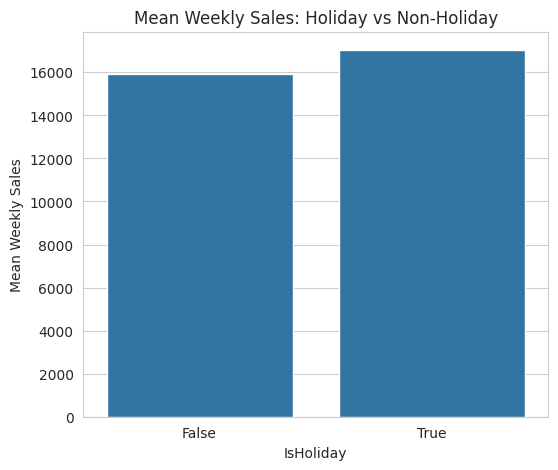

In [24]:
holiday_means = df.groupby('IsHoliday')['Weekly_Sales'].mean()
print(holiday_means)

plt.figure(figsize=(6, 5))
sns.barplot(x=holiday_means.index, y=holiday_means.values)
plt.title('Mean Weekly Sales: Holiday vs Non-Holiday')
plt.ylabel('Mean Weekly Sales')
plt.show()

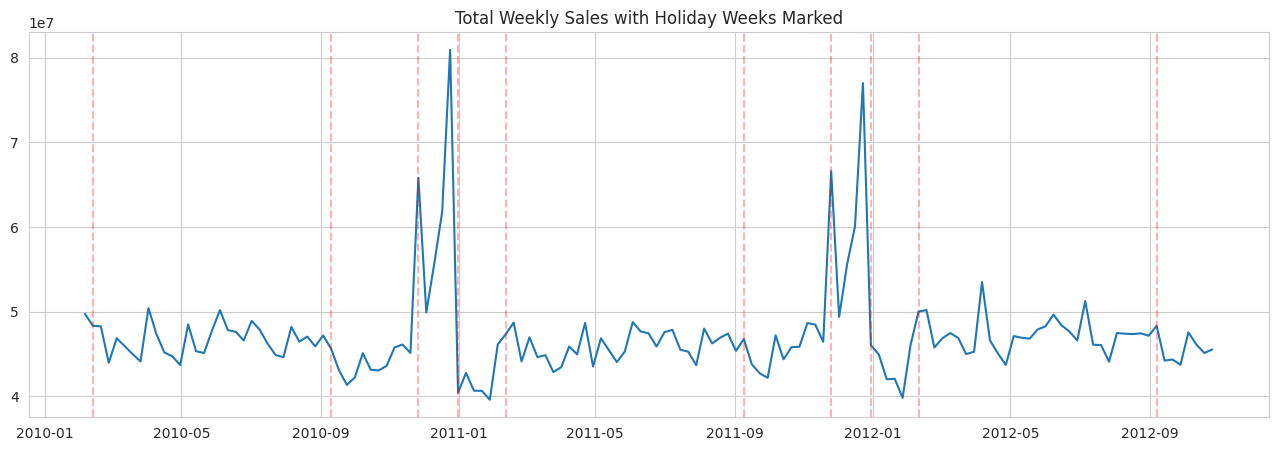

In [25]:
weekly_total_indexed = weekly_total.set_index('Date')

plt.figure(figsize=(16, 5))
plt.plot(weekly_total_indexed.index, weekly_total_indexed['Weekly_Sales'])
holiday_dates = df[df['IsHoliday']]['Date'].unique()
for hd in holiday_dates:
    plt.axvline(pd.Timestamp(hd), color='red', alpha=0.3, linestyle='--')
plt.title('Total Weekly Sales with Holiday Weeks Marked')
plt.show()

# Store-Dept Series Length / Gaps

Total weeks in dataset: 143
count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
Name: n_weeks, dtype: float64


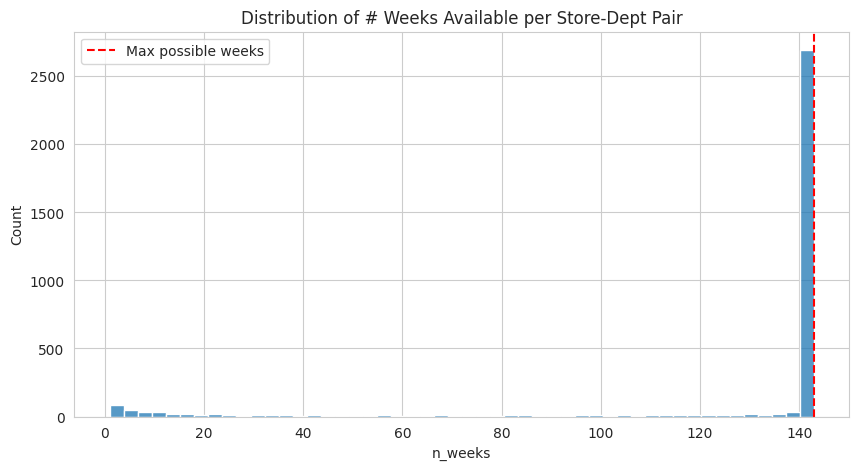

Store-Dept pairs with missing weeks: 671 out of 3331


In [26]:
store_dept_counts = df.groupby(['Store', 'Dept'])['Date'].count().reset_index(name='n_weeks')
total_weeks = df['Date'].nunique()

print("Total weeks in dataset:", total_weeks)
print(store_dept_counts['n_weeks'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(store_dept_counts['n_weeks'], bins=50)
plt.title('Distribution of # Weeks Available per Store-Dept Pair')
plt.axvline(total_weeks, color='red', linestyle='--', label='Max possible weeks')
plt.legend()
plt.show()

incomplete = store_dept_counts[store_dept_counts['n_weeks'] < total_weeks]
print(f"Store-Dept pairs with missing weeks: {len(incomplete)} out of {len(store_dept_counts)}")

Pairs with <   4 weeks:   86  (2.58%)
Pairs with <   8 weeks:  139  (4.17%)
Pairs with <  13 weeks:  196  (5.88%)
Pairs with <  26 weeks:  272  (8.17%)
Pairs with <  52 weeks:  340  (10.21%)
Pairs with < 104 weeks:  463  (13.90%)

Detailed breakdown below 52 weeks:
count    340.000000
mean      14.573529
std       13.505070
min        1.000000
25%        3.000000
50%       10.000000
75%       22.000000
max       51.000000
Name: n_weeks, dtype: float64


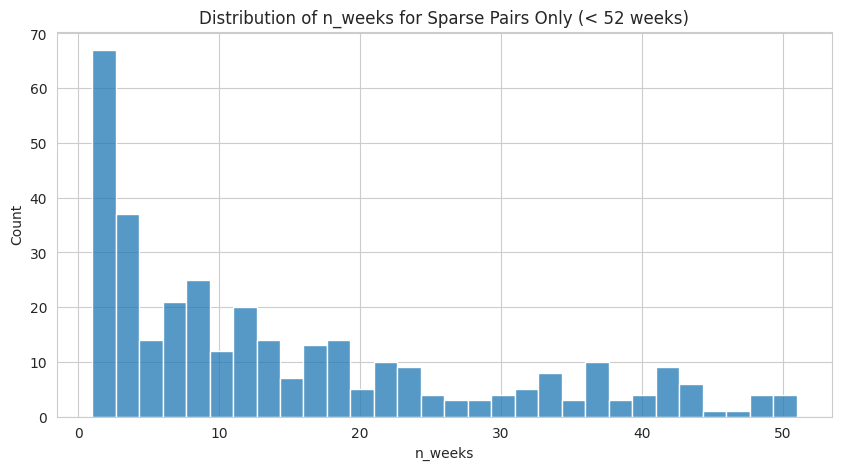

In [37]:
thresholds = [4, 8, 13, 26, 52, 104]

for t in thresholds:
    n_below = (store_dept_counts['n_weeks'] < t).sum()
    pct_below = n_below / len(store_dept_counts) * 100
    print(f"Pairs with < {t:>3} weeks: {n_below:>4}  ({pct_below:.2f}%)")

print()
print("Detailed breakdown below 52 weeks:")
print(store_dept_counts[store_dept_counts['n_weeks'] < 52]['n_weeks'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(store_dept_counts[store_dept_counts['n_weeks'] < 52]['n_weeks'], bins=30)
plt.title('Distribution of n_weeks for Sparse Pairs Only (< 52 weeks)')
plt.show()

# Individual Series Examples (high-volume vs low-volume)

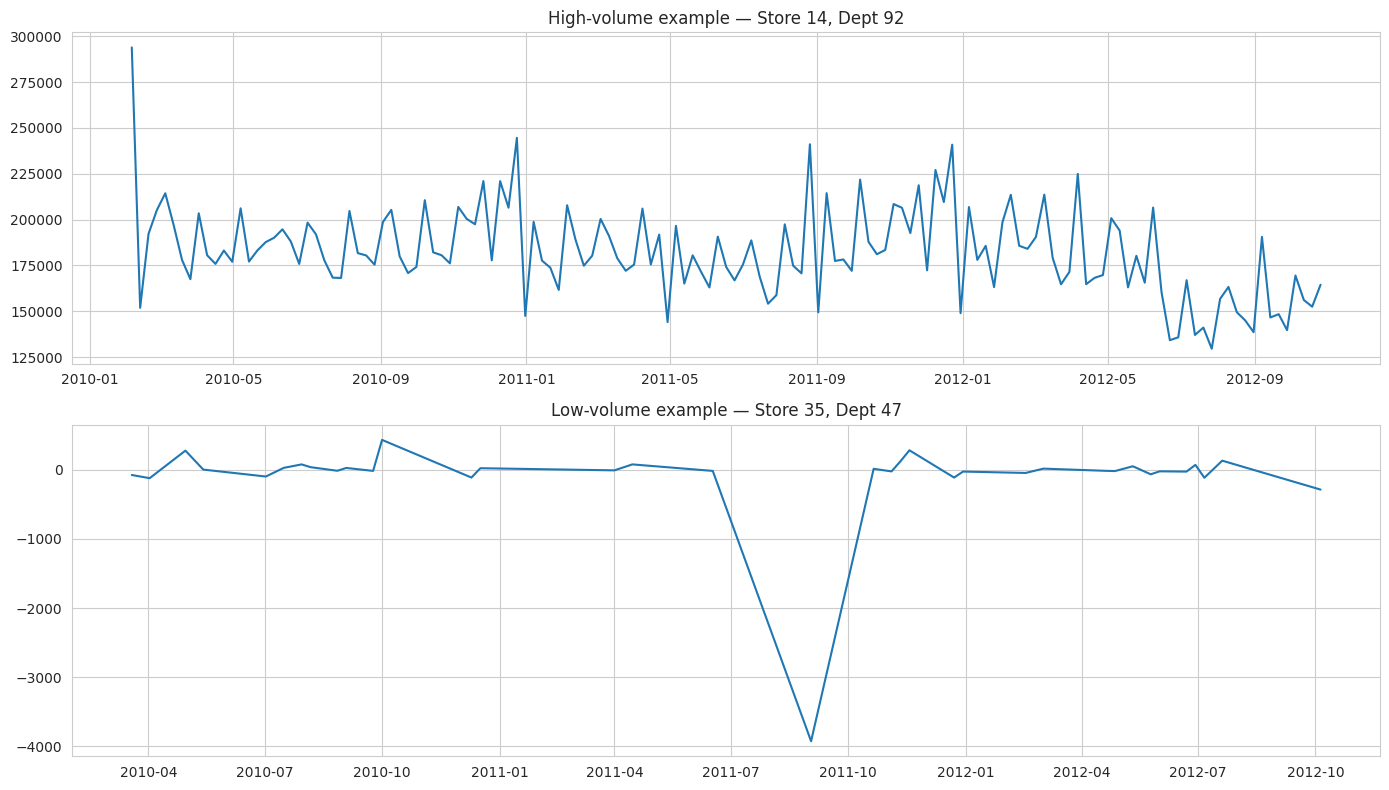

In [27]:
totals_by_pair = df.groupby(['Store', 'Dept'])['Weekly_Sales'].sum().sort_values()

low_store, low_dept = totals_by_pair.index[0]
high_store, high_dept = totals_by_pair.index[-1]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, (s, d), label in zip(axes, [(high_store, high_dept), (low_store, low_dept)], ['High-volume', 'Low-volume']):
    subset = df[(df['Store'] == s) & (df['Dept'] == d)].sort_values('Date')
    ax.plot(subset['Date'], subset['Weekly_Sales'])
    ax.set_title(f'{label} example — Store {s}, Dept {d}')

plt.tight_layout()
plt.show()

#  Store Type and Size

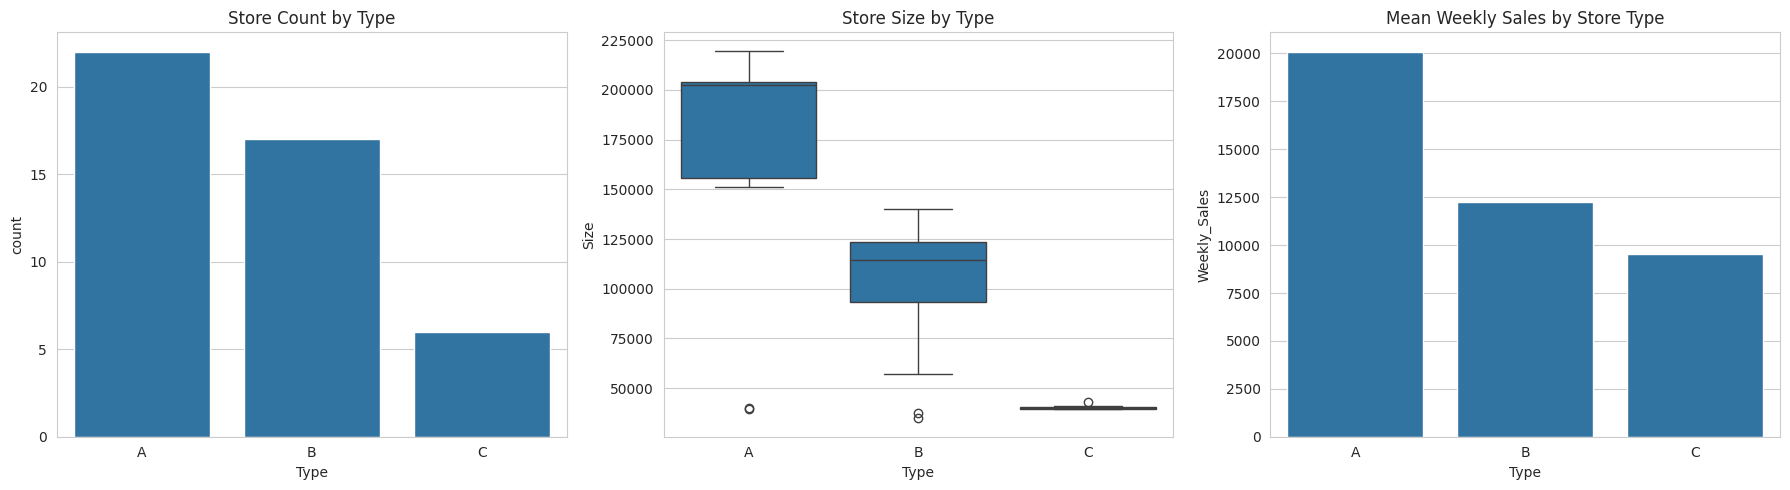

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='Type', data=stores, ax=axes[0])
axes[0].set_title('Store Count by Type')

sns.boxplot(x='Type', y='Size', data=stores, ax=axes[1])
axes[1].set_title('Store Size by Type')

type_sales = df.groupby('Type')['Weekly_Sales'].mean().reset_index()
sns.barplot(x='Type', y='Weekly_Sales', data=type_sales, ax=axes[2])
axes[2].set_title('Mean Weekly Sales by Store Type')

plt.tight_layout()
plt.show()

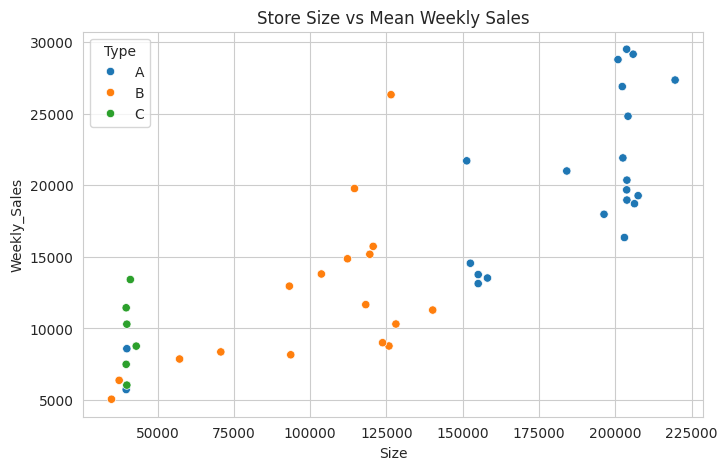

In [29]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.groupby('Store').agg({'Size':'first', 'Weekly_Sales':'mean', 'Type':'first'}).reset_index(),
                 x='Size', y='Weekly_Sales', hue='Type')
plt.title('Store Size vs Mean Weekly Sales')
plt.show()

# Economic Features vs Sales

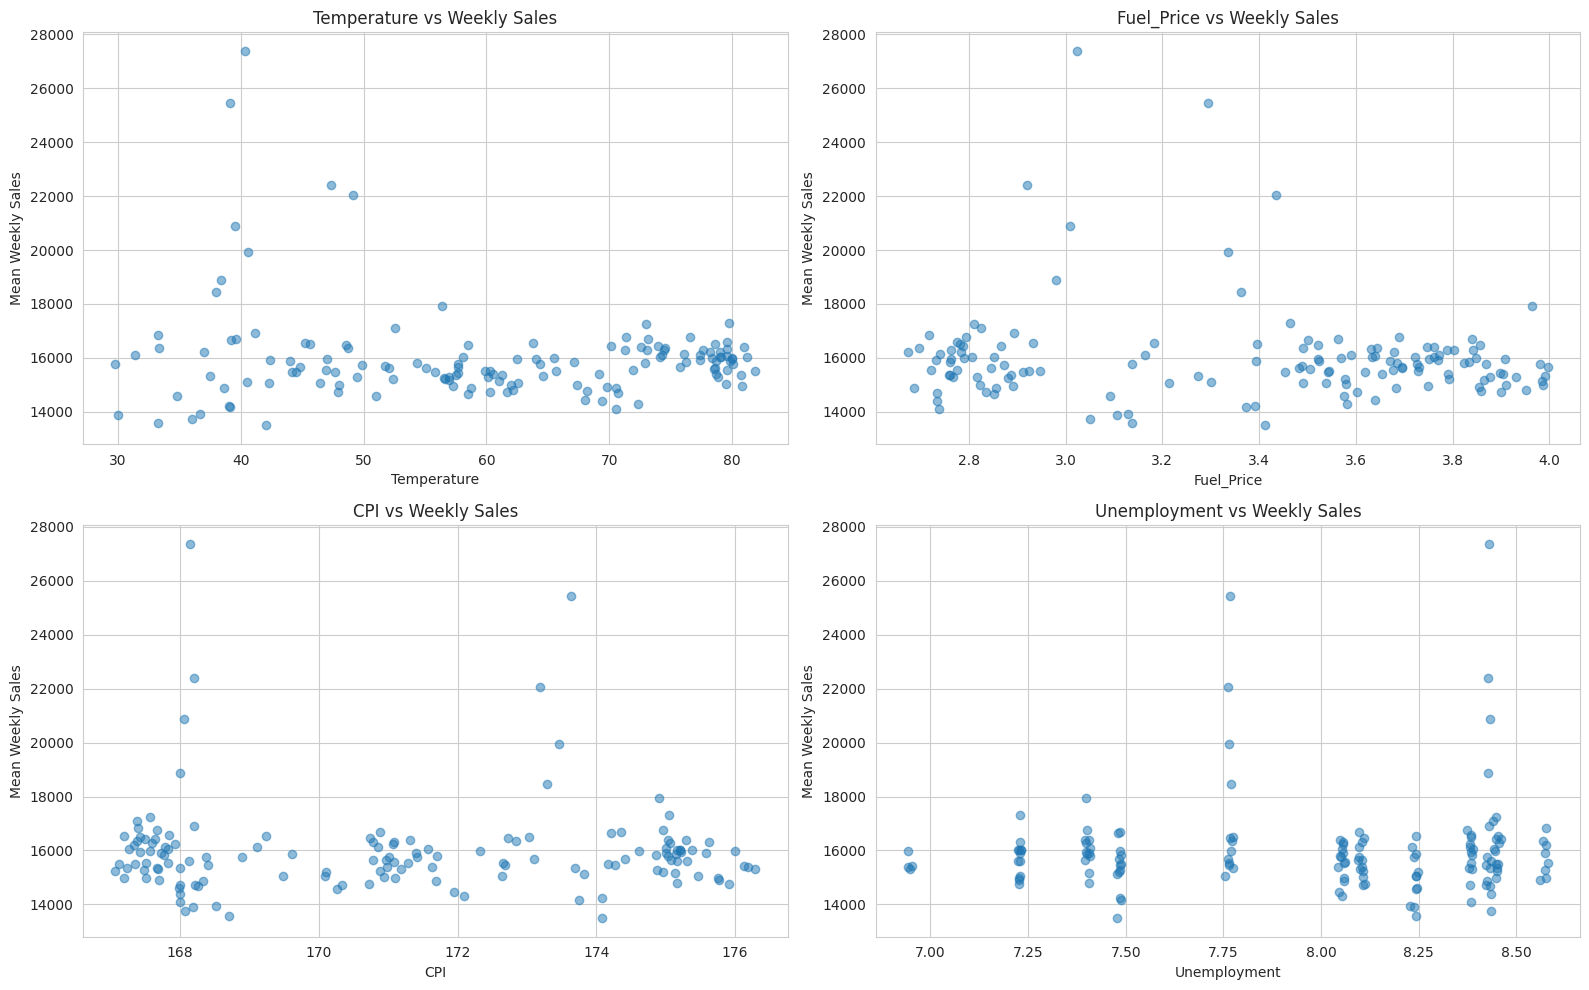

In [30]:
econ_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

weekly_econ = df.groupby('Date')[econ_cols + ['Weekly_Sales']].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flatten(), econ_cols):
    ax.scatter(weekly_econ[col], weekly_econ['Weekly_Sales'], alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel('Mean Weekly Sales')
    ax.set_title(f'{col} vs Weekly Sales')

plt.tight_layout()
plt.show()

# Correlation Heatmap

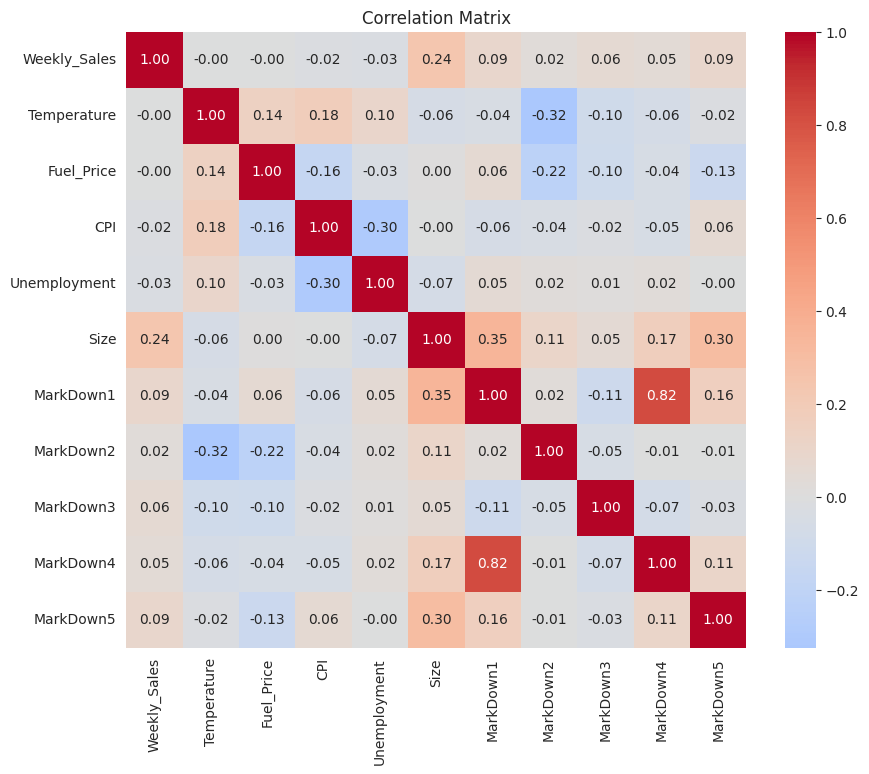

In [31]:
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size'] + markdown_cols

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Stationarity Check (Aggregate Series)

In [32]:
result = adfuller(weekly_total_indexed['Weekly_Sales'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Stationary' if result[1] < 0.05 else 'Non-stationary')

ADF Statistic: -5.9083
p-value: 0.0000
Stationary


# ACF / PACF Plots

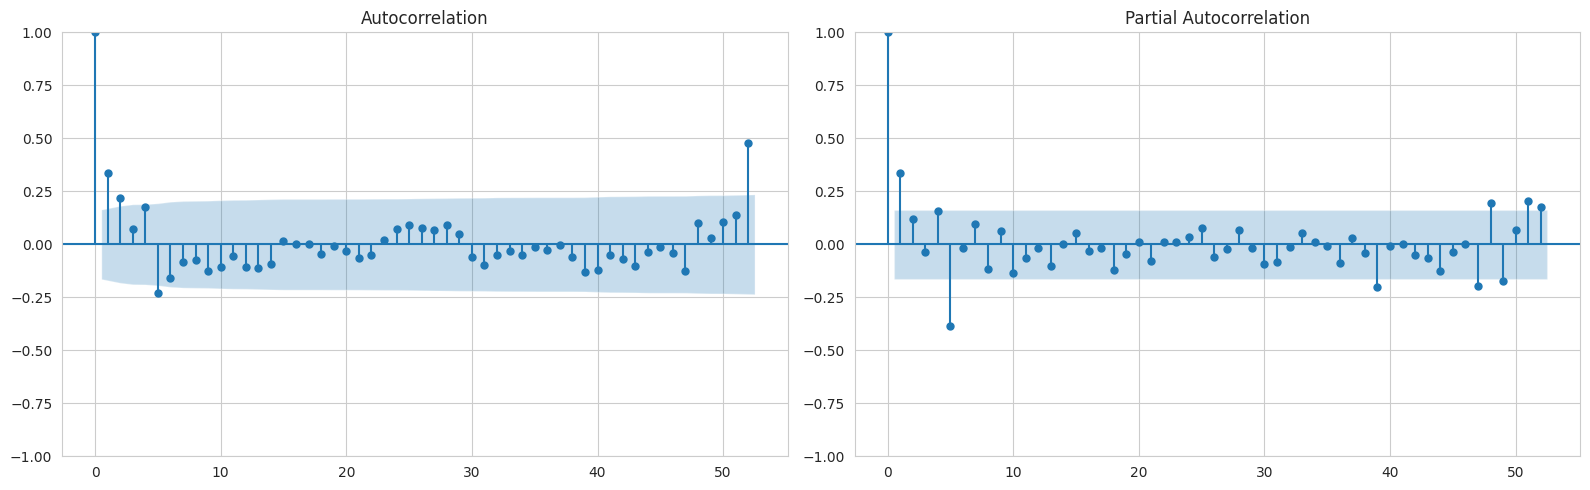

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(weekly_total_indexed['Weekly_Sales'], lags=52, ax=axes[0])
plot_pacf(weekly_total_indexed['Weekly_Sales'], lags=52, ax=axes[1])
plt.tight_layout()
plt.show()

# Seasonal Decomposition

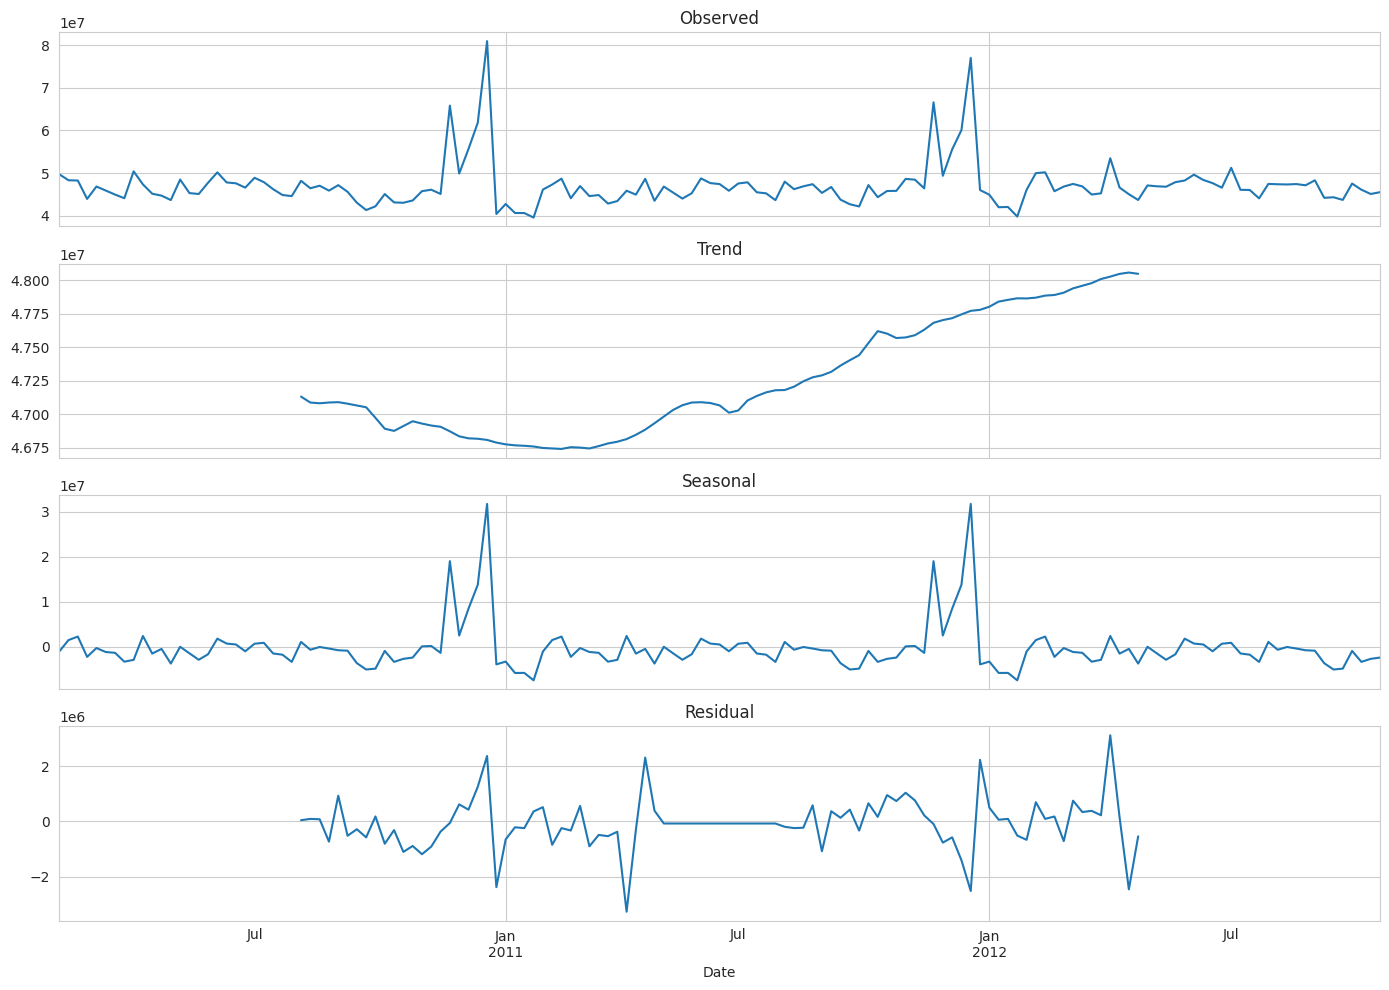

In [36]:
decomposition = seasonal_decompose(weekly_total_indexed['Weekly_Sales'], model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

# EDA Summary and Decisions

- **MarkDown columns**: 64-74% missing, structurally missing (not tracked early in dataset).
  Decision: fill NaN with 0.
- **Negative Weekly_Sales**: 1,285 rows (~0.3%), plausible returns-exceed-sales weeks.
  Decision: keep as-is; do not clip or drop.
- **Store-Dept series length**: 3,331 pairs total, median 143/143 weeks.
  340 pairs (10.21%) have < 52 weeks of history, and within that group the
  median is only 10 weeks (mostly very short series, not near-complete ones).
  Decision: exclude pairs with < 52 weeks for per-series classical/DL models
  (ARIMA/SARIMA/Prophet/N-BEATS/DLinear/TFT/PatchTST) since they can't
  reliably estimate a yearly seasonal cycle from less than a year of data.
  Tree-based models (XGBoost/LightGBM) keep all 3,331 pairs, using
  Store/Dept as categorical features, since they don't need a full
  seasonal cycle per series.
- **Stationarity (aggregate)**: ADF p=0.0000 -> stationary, no strong trend.
  Decision: minimal non-seasonal differencing needed; still apply seasonal
  differencing (D=1, period=52) for SARIMA due to visible yearly seasonality.
- **Train/validation split**: time-based, hold out last ~8-12 weeks (no random shuffle).
- **Core engineered features**: lag_1, lag_52, rolling_mean_4/8, IsHoliday,
  week_of_year, days_to_nearest_holiday.